C:\Users\Epic_Ice\PycharmProjects\labML2_2\.venv\lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


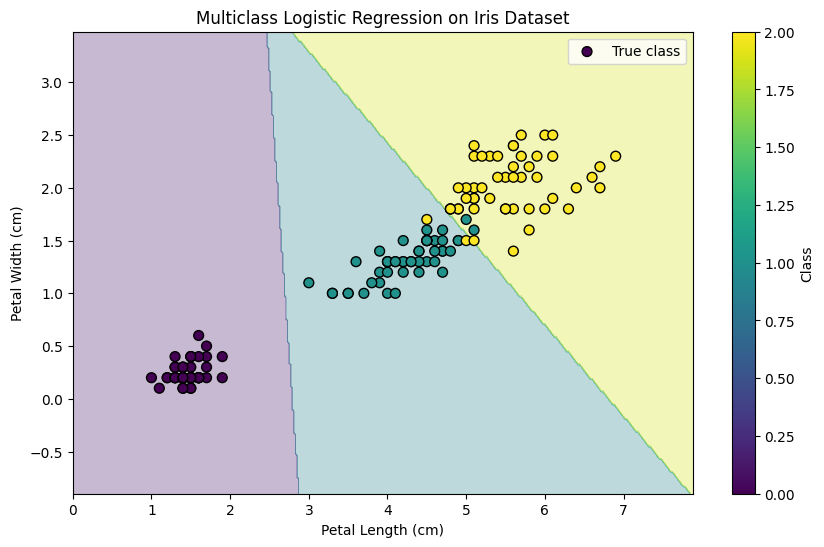

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression

# Загрузка данных Iris
iris = load_iris()
# Используем только длину и ширину лепестка (столбцы 2 и 3)
X = iris.data[:, 2:]
y = iris.target  # Метки классов (0: setosa, 1: versicolor, 2: virginica)

# Создаем и обучаем модель логистической регрессии для многоклассовой классификации
clf = LogisticRegression(multi_class='multinomial',  # Для многоклассовой классификации
                        solver='lbfgs',            # Алгоритм оптимизации
                        max_iter=1000)             # Увеличиваем число итераций для надежности
clf.fit(X, y)

# Создаем сетку для построения границы решений
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# Предсказываем класс для каждой точки сетки
Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Визуализация
plt.figure(figsize=(10, 6))
# Рисуем области решений
plt.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')
# Рисуем исходные точки данных
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis',
            edgecolor='k', s=50, label='True class')
# Настройки графика
plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.title('Multiclass Logistic Regression on Iris Dataset')
plt.legend()
plt.colorbar(label='Class')
plt.show()